# Analytic Continuation and the Zeta function


The second false proof that this sum converges is quite sophisticated and it is going to lead us deep into the realm 
of complex analysis and analytic continuation.

### Rieman's Zeta Function

Define $ζ(k) = \sum_{n=0}^{\infty} n^{-k}$

It is relatively easy to prove that these sequence converges for $n > 1$ but diverges for 
$n\leq 1$.


Riemann expanded the defition from the integers to the complex plane
$ζ(s) = \sum_{n=0}^{\infty} n^{-s}$

and demonstrated that the sequence converges to an analytic function in the region 
$Re(s) > 1$

### Complex Numbers

Complex numbers are numbers of the form $a+ib$ where a,b are real numbers and i is the *imaginary unit*, 
which has the property $i^2 = -1$. The set of all complex numbers is denoted by $\mathbb{C}$.
Pretty much all the common functions that we know from calculus, such as sine, cosine, exponential, logarithm, polynomials et cetera, can be extened to functions of complex numbers.



### Analytic Functions and Analytic Continuation

A function $f$ is called *analytic* at a point if, near that point, it agrees with its own convergent
power series (its Taylor series). A function is analytic on a domain if this holds at every point of
that domain. Analytic functions are extremely rigid: if two analytic functions agree on any small open
region (or even just a curve, or a sequence of points with an accumulation point), they must agree
everywhere both are defined. This rigidity — sometimes called the *identity theorem* — is what makes
the following idea work.

Suppose a power series $f(z) = \sum a_n z^n$ converges only inside some disk (say $|z|<1$), but its sum
happens to equal a closed-form expression $g(z)$ that is itself analytic on some much larger domain. Since
$f=g$ everywhere the series converges, and analytic functions are rigid, $g$ is the *unique* analytic
function on the larger domain that agrees with $f$ wherever $f$ is defined. We call $g$ the *analytic
continuation* of $f$. Crucially, $g(z)$ can be evaluated at points where the original series $\sum a_n z^n$
diverges — $g$ simply is not given by that series there.

The simplest possible example is the geometric series. $f(x) = \sum_{n=0}^{\infty} x^n$ only converges
for $|x|<1$, where it equals $\frac{1}{1-x}$. But $\frac{1}{1-x}$ is a perfectly good analytic function
everywhere except at $x=1$ — so $\frac{1}{1-x}$ is the analytic continuation of the geometric series to
all of $\mathbb{R}\setminus\{1\}$ (or, treating $x$ as complex, to all of $\mathbb{C}\setminus\{1\}$). The
plot below makes this concrete: the partial sums of the series track $\frac{1}{1-x}$ closely inside
$|x|<1$, but diverge wildly outside it, while $\frac{1}{1-x}$ itself stays perfectly smooth all the way
up to $x=1$.

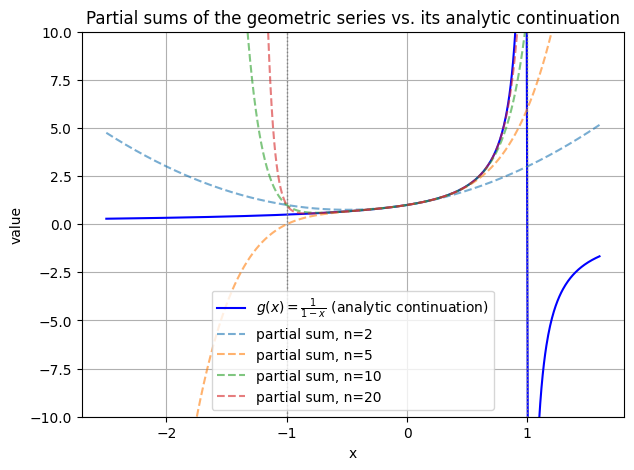

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2.5, 1.6, 800)
x_closed_form = x[np.abs(x - 1) > 0.02]

plt.figure(figsize=(7, 5))
plt.plot(x_closed_form, 1 / (1 - x_closed_form), color='b', label=r'$g(x) = \frac{1}{1-x}$ (analytic continuation)')

for n in [2, 5, 10, 20]:
    partial_sum = sum(x**k for k in range(n + 1))
    plt.plot(x, partial_sum, '--', alpha=0.6, label=f'partial sum, n={n}')

plt.axvline(1, color='gray', linestyle=':', linewidth=1)
plt.axvline(-1, color='gray', linestyle=':', linewidth=1)
plt.ylim(-10, 10)
plt.title('Partial sums of the geometric series vs. its analytic continuation')
plt.xlabel('x')
plt.ylabel('value')
plt.legend()
plt.grid(True)
plt.show()

The same pattern applies to $\zeta(s) = \sum_{n=1}^{\infty} n^{-s}$: the series only converges for
$\mathrm{Re}(s) > 1$, but it turns out to agree there with a closed-form expression that is analytic
almost everywhere on $\mathbb{C}$ (everywhere except at $s=1$, where $\zeta$ has a pole). That closed-form
expression is $\zeta$'s analytic continuation, and just like $\frac{1}{1-x}$ above, it can be evaluated
at points — such as $s=-1$ — where the defining series diverges.

The analytic extension of this function has a (more or less) closed-form expression

<img src="zeta.svg"/>

<img src="zeta-functional.svg"/>

You can use either the integral or the fn equation form to evaluate $\zeta(-1) = -1/12$. 
It is easier using the funcitonal form. 

This leads people to say that since $\zeta(-1) = -1/12$, then 
$\sum_{k=0}^{\infty} k = -1/12$.

But this is incorrect because the summation expression for the zeta function only holds in the region Re(s)>1 and not in the rest of the complex plane. We can use either of the the other expression in the rest of the plane but not the summation.


### Visualizing the Zeta function

The distinction between "the series" and "the analytic continuation" is much easier to see than to read
about. Below is the same style of picture 3Blue1Brown uses in his video on the topic: take a dense grid
of vertical and horizontal lines in the $s$-plane, and plot where $\zeta$ sends each of them in the
output ($w=\zeta(s)$) plane. With enough lines, the picture reads as a continuously warped colored fabric,
revealing how $\zeta$ distorts the plane. We do this first using the defining series directly (which only
makes sense for $\mathrm{Re}(s)>1$), and then using `mpmath`'s built-in $\zeta$, which implements the full
analytic continuation to (almost) the whole plane.

These images are generated by `generate_zeta_plots.py` in this repository rather than computed live in
this notebook — the continuation plot calls `mpmath.zeta` once per grid point (it isn't vectorized), so
producing a dense, high-quality image takes on the order of a minute, too slow to be worth re-running
every time this notebook executes.

<img src="zeta-direct.png"/>

In this region the grid comes out mostly mildly distorted, aside from a tight tangle right around $s=1$
(where the pole starts to make its presence felt even from the $\mathrm{Re}(s)>1$ side). Away from that,
the lines stay smooth and well-separated — exactly what we'd expect from a well-behaved convergent
function. This picture gives us no way to say anything at all about $s=-1$, since the sum simply doesn't
converge there. Now we extend the picture using the full analytic continuation instead of the raw series,
sweeping the input grid across a much wider region including the critical strip and the negative real
axis.

<img src="zeta-continuation.png"/>

The grid is now dramatically warped compared to the first picture — the lines form a six-petal flower
pattern, spiraling densely around two special points: the bright core near $s=1$, which is the pole
($|\zeta(s)|\to\infty$ there), and the point marked $\zeta(-1)=-\frac{1}{12}$ off to its left. That second
point sits in perfectly ordinary, well-defined territory on this extended picture — even though the
defining series $\sum n^{-s}$ has no meaning there at all. That gap is exactly the fallacy from the start
of this article: $\zeta(-1)=-\frac{1}{12}$ is a fact about the continuation, not about the series
$1+2+3+\ldots$ itself.

### A note on the Riemann Hypothesis

Since $\zeta$ has come up, it's worth a brief aside on the *Riemann Hypothesis*, arguably the most famous
unsolved problem in mathematics — even though it has nothing directly to do with the $-\frac{1}{12}$
paradox. Besides the "trivial" zeros of $\zeta$ at the negative even integers $-2,-4,-6,\ldots$ (a
consequence of the functional equation shown above), $\zeta$ has infinitely many other, "non-trivial"
zeros, all known to lie in the *critical strip* $0 < \mathrm{Re}(s) < 1$. The Riemann Hypothesis
conjectures that every one of them lies exactly on the *critical line* $\mathrm{Re}(s)=\frac{1}{2}$. It
remains unproven, and its truth or falsity has deep consequences for the distribution of prime numbers.
It is unrelated to the value of $\zeta(-1)$, which lies well outside the critical strip and is already
known exactly.

### References
- https://www.youtube.com/watch?v=sD0NjbwqlYw
- https://en.wikipedia.org/wiki/Riemann_zeta_function
- https://en.wikipedia.org/wiki/Zeta_function_regularization
- https://www.3blue1brown.com/lessons/zeta (grid-transformation visualization style)
- https://github.com/3b1b/videos/blob/master/_2016/zeta.py (original source for the visualization)
